# TP Jour 1 — Préparer la base pour la modélisation du Jour 2

Vous devez produire une base propre et documentée.  
**Ne construisez pas encore le modèle final.**

Livrables :
1. `data_J1_clean.csv`
2. `dictionnaire_donnees.md`
3. notebook complété et commenté


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## A. Audit

In [2]:
df = pd.read_csv("../data/data_J1_brut.csv")
# TODO : shape, head, info, describe, NA, doublons, cardinalités
df.shape

(423, 10)

In [3]:
df.head(3)

,machine_id,ville,type_machine,risque,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
0,M0001,Abomey-Calavi,Compresseur,Faible,NaN,3.00,6.65,13,21256.0,0
1,M0002,Cotonou,Moteur,Moyen,65.0,3.37,6.72,10,28487.0,0
2,M0003,Parakou,Pompe,Faible,77.5,NaN,7.11,15,20511.0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   machine_id       423 non-null    str    
 1   ville            423 non-null    str    
 2   type_machine     411 non-null    str    
 3   risque           423 non-null    str    
 4   temperature_C    401 non-null    float64
 5   vibration        395 non-null    float64
 6   pression_bar     403 non-null    float64
 7   age_ans          423 non-null    int64  
 8   production_jour  423 non-null    float64
 9   panne            423 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 33.2 KB


In [5]:
df.describe()

,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
count,401.000000,395.000000,403.000000,423.000000,423.000000,423.000000
mean,71.091521,3.807247,6.914243,9.033097,25138.876470,0.004728
std,8.658607,2.076071,0.552058,4.768463,9495.106460,0.068680
min,39.000000,-0.230000,5.520000,1.000000,8291.000000,0.000000
25%,66.000000,2.745000,6.495000,5.000000,19832.500000,0.000000
50%,70.600000,3.680000,6.980000,9.000000,24234.000000,0.000000
75%,76.400000,4.535000,7.290000,13.000000,29255.000000,0.000000
max,145.000000,27.474498,8.270000,17.000000,113005.631236,1.000000


In [6]:
df.isna()

,machine_id,ville,type_machine,risque,temperature_C,vibration,pression_bar,age_ans,production_jour,panne
0,False,False,False,False,True,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
418,False,False,False,False,False,True,False,False,False,False
419,False,False,False,False,False,False,False,False,False,False
420,False,False,False,False,False,False,False,False,False,False
421,False,False,False,False,False,False,False,False,False,False


In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
418    False
419    False
420     True
421     True
422     True
Length: 423, dtype: bool

In [8]:
df.nunique()

machine_id         420
ville                4
type_machine         3
risque               3
temperature_C      218
vibration          279
pression_bar       193
age_ans             17
production_jour    417
panne                2
dtype: int64

### Challenge A
Construisez un tableau d'audit avec :
- type
- nombre de NA
- %
- nombre de valeurs uniques
- décision de traitement proposée


In [9]:
audit_df = pd.DataFrame({
    'type': df.dtypes,
    'nombre de NA': df.isna().sum(),
    'nombre de valeurs uniques': df.nunique()
})

audit_df['%'] = ((audit_df['nombre de NA'] / len(df)) * 100).round(2).astype(str) + ' %'


def determiner_decision(row):
    na_count = row['nombre de NA']
    na_pct = (na_count / len(df)) * 100
    unique_count = row['nombre de valeurs uniques']
    col_type = str(row['type'])
    nom_colonne = str(row.name)
    ratio_unique = unique_count / len(df)

    # Une colonne quasi-unique n'est un identifiant que si elle est textuelle ou nommée
    # comme telle -- sinon une simple mesure continue (ex: production_jour, 98.6% unique
    # car ce sont des mesures réelles) serait, à tort, étiquetée comme identifiant.
    est_id_probable = (
        ratio_unique >= 0.95
        and ('object' in col_type or 'str' in col_type or 'id' in nom_colonne.lower())
    )

    if unique_count == 1:
        return "Supprimer colonne (valeur unique constante)"
    elif est_id_probable:
        # Corrigé : un identifiant est presque toujours de type texte (object/str),
        # donc on ne doit PAS l'exclure sur ce critère (l'ancienne condition
        # "col_type != 'object'" excluait justement les IDs textuels, l'inverse
        # de ce qu'il faut). On utilise aussi un seuil >=95% plutôt qu'une égalité
        # stricte à len(df), car des doublons (3 lignes, repérés plus haut) font
        # que machine_id n'est pas à 100% unique -- et on exige en plus un type
        # texte ou un nom évocateur pour ne pas confondre avec une mesure continue.
        return "Identifiant probable (clé) : conserver pour traçabilité, exclure de la modélisation"
    elif na_pct > 50:
        return "Supprimer colonne (>50% de NA)"
    elif na_count > 0:
        if 'float' in col_type or 'int' in col_type:
            return "Imputer (médiane ou moyenne)"
        else:
            return "Imputer (mode ou 'Inconnu')"
    else:
        return "RAS (Données complètes)"

audit_df['décision de traitement proposée'] = audit_df.apply(determiner_decision, axis=1)

audit_df

,type,nombre de NA,nombre de valeurs uniques,%,décision de traitement proposée
machine_id,str,0,420,0.0 %,Identifiant probable (clé) : conserver pour tr...
ville,str,0,4,0.0 %,RAS (Données complètes)
type_machine,str,12,3,2.84 %,Imputer (mode ou 'Inconnu')
risque,str,0,3,0.0 %,RAS (Données complètes)
temperature_C,float64,22,218,5.2 %,Imputer (médiane ou moyenne)
vibration,float64,28,279,6.62 %,Imputer (médiane ou moyenne)
pression_bar,float64,20,193,4.73 %,Imputer (médiane ou moyenne)
age_ans,int64,0,17,0.0 %,RAS (Données complètes)
production_jour,float64,0,417,0.0 %,RAS (Données complètes)
panne,int64,0,2,0.0 %,RAS (Données complètes)


## B. Données manquantes — MCAR / MAR / MNAR

In [10]:
# Analyse du taux de NA selon une variable observée (ville) plutôt que machine_id
# (machine_id est quasi unique -> pas pertinent pour comparer des taux de NA)

na_par_ville = df.groupby('ville')[['temperature_C', 'vibration', 'pression_bar']].apply(
    lambda x: (x.isna().mean() * 100).round(1)
)
print("Taux de NA (%) par ville :")
na_par_ville


Taux de NA (%) par ville :


,temperature_C,vibration,pression_bar
ville,,,
Abomey-Calavi,5.3,0.0,6.7
Cotonou,6.4,0.0,5.8
Parakou,2.2,30.1,3.2
Porto-Novo,6.0,0.0,2.4


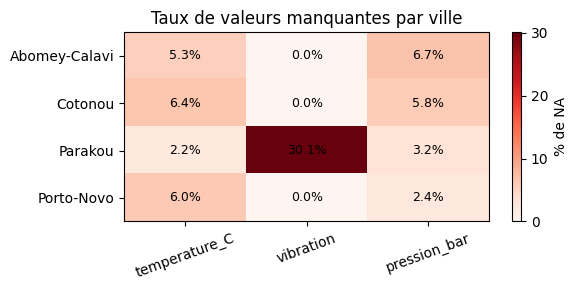

In [11]:
# Visualisation : heatmap simple des NA par ville
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(na_par_ville.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(na_par_ville.columns)))
ax.set_xticklabels(na_par_ville.columns, rotation=20)
ax.set_yticks(range(len(na_par_ville.index)))
ax.set_yticklabels(na_par_ville.index)
for i in range(na_par_ville.shape[0]):
    for j in range(na_par_ville.shape[1]):
        ax.text(j, i, f"{na_par_ville.values[i, j]}%", ha='center', va='center', fontsize=9)
plt.colorbar(im, label='% de NA')
plt.title("Taux de valeurs manquantes par ville")
plt.tight_layout()
plt.show()


**Constat clé** : le taux de NA de `vibration` est de 0 % à Abomey-Calavi, Cotonou et Porto-Novo, mais de **30,1 % à Parakou** (28 valeurs manquantes sur 93). Les NA de `temperature_C` et `pression_bar`, eux, sont répartis de façon comparable entre les 4 villes (2 à 7 %).

**Diagnostic par variable :**

- **`vibration` → MAR (Missing At Random).** L'absence dépend d'une variable observée (`ville`), pas de la valeur de vibration elle-même. Hypothèse métier la plus plausible : un capteur de vibration défectueux ou un problème de collecte/transmission spécifique au site de Parakou (ex. capteur non calibré, coupure réseau récurrente sur ce site).
- **`temperature_C` → probablement MCAR (Missing Completely At Random).** Le taux de NA (2 à 7 %) est stable selon la ville, le type de machine et le statut de panne — rien n'indique que l'absence dépende d'une variable connue ou de la valeur manquante elle-même. Cohérent avec des pannes ponctuelles de capteur, indépendantes du contexte.
- **`pression_bar` → probablement MCAR également**, pour les mêmes raisons (taux homogène entre groupes, ~2,4 à 6,7 %).

On ne peut pas exclure un mécanisme **MNAR** (ex. le capteur de température décroche justement quand la température est extrême) sans données externes (logs de capteurs) pour le confirmer — c'est une limite à noter dans les conclusions.


## C. Nettoyage et imputation

In [12]:
# Contrôle de vraisemblance physique AVANT imputation :
# une vibration ne peut pas être négative -> ce sont des valeurs invalides, pas juste des
# outliers statistiques. On les traite comme des NA avant l'étape d'imputation.
print("Valeurs négatives de vibration :", (df['vibration'] < 0).sum())
df.loc[df['vibration'] < 0, 'vibration'] = pd.NA


Valeurs négatives de vibration : 2


On force ces 2 valeurs négatives (`-0.07`, `-0.23`) à NA car elles sont physiquement impossibles, avant de les imputer avec le reste des `vibration` manquantes (logique MAR par ville, cf. partie B).

In [13]:
# 1. Doublons : on avait détecté 3 lignes dupliquées (df.duplicated().sum() == 3)
clean_df = df.drop_duplicates().copy()
print(f"Lignes avant : {len(df)} -> après suppression des doublons : {len(clean_df)}")

# 2. Valeurs manquantes catégorielles : type_machine (12 NA)
#    -> catégorie 'Inconnu' plutôt que le mode, car on ne veut pas fabriquer une fausse
#       certitude sur le type de machine (donnée métier importante, pas juste un détail).
clean_df['type_machine'] = clean_df['type_machine'].fillna('Inconnu')

# 3. Valeurs manquantes numériques : pression_bar, temperature_C (MCAR) -> imputation par la
#    médiane (robuste aux quelques valeurs extrêmes déjà repérées, ex. temperature_C = 145).
for col in ['temperature_C', 'pression_bar']:
    med = clean_df[col].median()
    clean_df[col] = clean_df[col].fillna(med)
    print(f"{col} : imputé par la médiane = {med}")

# 4. vibration (MAR, dépend de 'ville') -> imputation par la médiane PAR VILLE plutôt qu'une
#    médiane globale, pour respecter le mécanisme MAR identifié en partie B.
clean_df['vibration'] = clean_df.groupby('ville')['vibration'].transform(
    lambda x: x.fillna(x.median())
)

print("\nNA restants après nettoyage :")
print(clean_df.isna().sum())


Lignes avant : 423 -> après suppression des doublons : 420
temperature_C : imputé par la médiane = 70.6
pression_bar : imputé par la médiane = 6.98

NA restants après nettoyage :
machine_id         0
ville              0
type_machine       0
risque             0
temperature_C      0
vibration          0
pression_bar       0
age_ans            0
production_jour    0
panne              0
dtype: int64


## D. Valeurs aberrantes

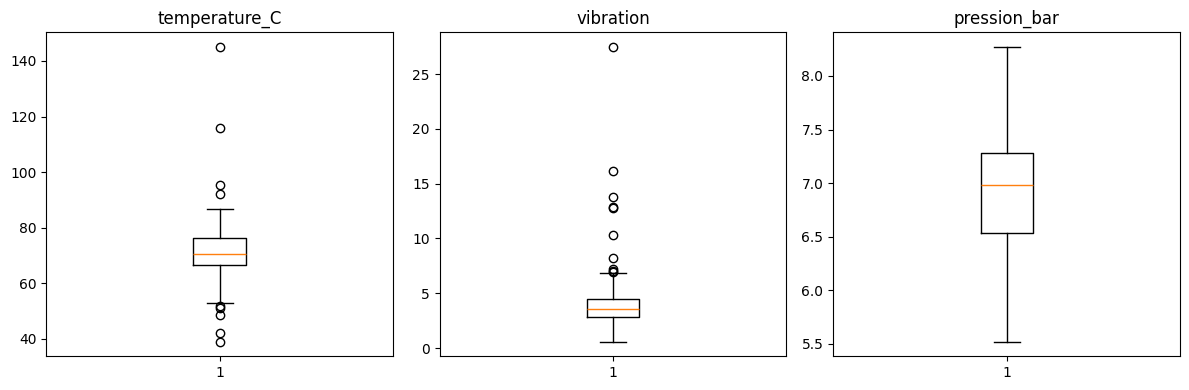

In [14]:
# TODO 1 : boxplot des 3 variables numériques sensibles
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['temperature_C', 'vibration', 'pression_bar']):
    ax.boxplot(clean_df[col].dropna())
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [15]:
# TODO 2 : méthode IQR
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (s < lo) | (s > hi)

iqr_flags = pd.DataFrame({col: iqr_outliers(clean_df[col]) for col in ['temperature_C', 'vibration', 'pression_bar']})
print("Nombre d'outliers IQR par variable :")
print(iqr_flags.sum())


Nombre d'outliers IQR par variable :
temperature_C     9
vibration        10
pression_bar      0
dtype: int64


In [16]:
# TODO 3 : Z-score (sensible à la moyenne/écart-type, donc sensible aux outliers eux-mêmes)
from scipy import stats as sstats

zscore_flags = pd.DataFrame({
    col: (sstats.zscore(clean_df[col]).__abs__() > 3)
    for col in ['temperature_C', 'vibration', 'pression_bar']
})
print("Nombre d'outliers Z-score (|z|>3) par variable :")
print(zscore_flags.sum())


Nombre d'outliers Z-score (|z|>3) par variable :
temperature_C    4
vibration        6
pression_bar     0
dtype: int64


In [17]:
# TODO 4 : modified Z-score / MAD (robuste, basé sur la médiane -> préférable ici
# car nos variables contiennent déjà des valeurs extrêmes qui biaisent moyenne/écart-type)
def modified_zscore(s):
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0:
        return pd.Series(0, index=s.index)
    return 0.6745 * (s - med) / mad

mad_flags = pd.DataFrame({
    col: (modified_zscore(clean_df[col]).abs() > 3.5)
    for col in ['temperature_C', 'vibration', 'pression_bar']
})
print("Nombre d'outliers MAD (modified Z-score>3.5) par variable :")
print(mad_flags.sum())


Nombre d'outliers MAD (modified Z-score>3.5) par variable :


temperature_C    4
vibration        7
pression_bar     0
dtype: int64


In [18]:
# BONUS : Isolation Forest (multivarié -> détecte des combinaisons anormales,
# pas seulement des valeurs extrêmes variable par variable)
iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
iso_pred = iso.fit_predict(clean_df[['temperature_C', 'vibration', 'pression_bar']])
clean_df_iso_outlier = iso_pred == -1
print("Nombre d'outliers Isolation Forest (multivarié) :", clean_df_iso_outlier.sum())


Nombre d'outliers Isolation Forest (multivarié) : 13


### Challenge D
Créez un tableau comparatif :
`machine_id | IQR | Z-score | MAD | IsolationForest | décision métier`

Une détection n'est **pas** une suppression automatique.

In [19]:
# Challenge D : tableau comparatif machine_id | IQR | Z-score | MAD | IsolationForest | décision métier
comparatif = pd.DataFrame({
    'machine_id': clean_df['machine_id'].values,
    'IQR': iqr_flags.any(axis=1).values,
    'Z-score': zscore_flags.any(axis=1).values,
    'MAD': mad_flags.any(axis=1).values,
    'IsolationForest': clean_df_iso_outlier,
})
comparatif['nb_methodes_positives'] = comparatif[['IQR', 'Z-score', 'MAD', 'IsolationForest']].sum(axis=1)

def decision_metier(row):
    if row['nb_methodes_positives'] >= 3:
        return "Anomalie forte : à investiguer avec l'équipe terrain avant toute décision"
    elif row['nb_methodes_positives'] >= 1:
        return "Anomalie possible : conserver mais surveiller / flag pour le Jour 2"
    else:
        return "RAS"

comparatif['décision métier'] = comparatif.apply(decision_metier, axis=1)

# On n'affiche que les lignes flaguées par au moins une méthode (la plupart des ~423 lignes sont "RAS")
comparatif[comparatif['nb_methodes_positives'] > 0].sort_values('nb_methodes_positives', ascending=False)


,machine_id,IQR,Z-score,MAD,IsolationForest,nb_methodes_positives,décision métier
97,M0098,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
101,M0102,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
203,M0204,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
377,M0378,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
318,M0319,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
272,M0273,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
248,M0249,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
243,M0244,True,True,True,True,4,Anomalie forte : à investiguer avec l'équipe t...
205,M0206,True,True,True,False,3,Anomalie forte : à investiguer avec l'équipe t...
412,M0413,True,True,True,False,3,Anomalie forte : à investiguer avec l'équipe t...


**Décision métier (important : détection ≠ suppression).** On ne supprime aucune ligne flaguée. Les machines identifiées comme anomalies fortes (≥3 méthodes sur 4) seront signalées à l'équipe maintenance pour vérification physique du capteur ou de la machine — une valeur extrême de température ou de vibration peut être un vrai signal de panne imminente, pas juste du bruit. On garde une colonne de flag pour le Jour 2 plutôt que de retirer ces lignes du jeu de données.

## E. Encodage, normalisation, feature engineering

In [20]:
# --- Feature engineering (2 nouvelles features utiles, sans utiliser la cible 'panne') ---

# 1. production_par_age : production journalière rapportée à l'âge de la machine
#    -> une machine ancienne qui produit encore beaucoup peut être un signal différent
#       d'une machine jeune qui sur-produit.
clean_df['production_par_age'] = clean_df['production_jour'] / (clean_df['age_ans'] + 1)

# 2. ecart_temperature_type : écart de température par rapport à la moyenne de son type de machine
#    -> une pompe à 90°C n'a pas le même sens qu'un moteur à 90°C ; on relativise donc par groupe.
moyenne_temp_par_type = clean_df.groupby('type_machine')['temperature_C'].transform('mean')
clean_df['ecart_temperature_type'] = clean_df['temperature_C'] - moyenne_temp_par_type

print("Nouvelles colonnes :", ['production_par_age', 'ecart_temperature_type'])
clean_df[['machine_id', 'production_par_age', 'ecart_temperature_type']].head(3)


Nouvelles colonnes : ['production_par_age', 'ecart_temperature_type']


,machine_id,production_par_age,ecart_temperature_type
0,M0001,1518.285714,-0.481188
1,M0002,2589.727273,-6.482645
2,M0003,1281.937500,6.465054


In [21]:
# --- Encodage / normalisation ---
# IMPORTANT (anti-leakage) : on n'inclut PAS 'panne' (la cible du Jour 2) dans les features
# à encoder/normaliser, et 'machine_id' est un identifiant, pas une feature.

variables_nominales = ['ville', 'type_machine']          # pas d'ordre naturel -> OneHot
variables_numeriques = ['temperature_C', 'vibration', 'pression_bar', 'age_ans',
                         'production_jour', 'production_par_age', 'ecart_temperature_type']

# 'risque' est ORDINALE (Faible < Moyen < Élevé) : un OneHot ferait perdre cette information
# d'ordre, on utilise donc un mapping ordinal plutôt qu'un OneHotEncoder.
ordre_risque = {'Faible': 0, 'Moyen': 1, 'Élevé': 2}
clean_df['risque_ordinal'] = clean_df['risque'].map(ordre_risque)

preprocessor = ColumnTransformer(transformers=[
    ('nominal', OneHotEncoder(handle_unknown='ignore'), variables_nominales),
    ('numerique', StandardScaler(), variables_numeriques),
], remainder='drop')

features_transformees = preprocessor.fit_transform(clean_df)
noms_colonnes = (list(preprocessor.named_transformers_['nominal'].get_feature_names_out(variables_nominales))
                  + variables_numeriques)
features_df = pd.DataFrame(features_transformees, columns=noms_colonnes, index=clean_df.index)

print("Shape des features transformées :", features_df.shape)
features_df.head(3)


Shape des features transformées : (420, 15)


,ville_Abomey-Calavi,ville_Cotonou,ville_Parakou,ville_Porto-Novo,type_machine_Compresseur,type_machine_Inconnu,type_machine_Moteur,type_machine_Pompe,temperature_C,vibration,pression_bar,age_ans,production_jour,production_par_age,ecart_temperature_type
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.054952,-0.400323,-0.496125,0.837362,-0.407822,-0.713850,-0.057330
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.719804,-0.214578,-0.366321,0.207466,0.356294,-0.335122,-0.772358
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.764241,-0.154336,0.356873,1.257293,-0.486548,-0.797393,0.770262


## F. EDA

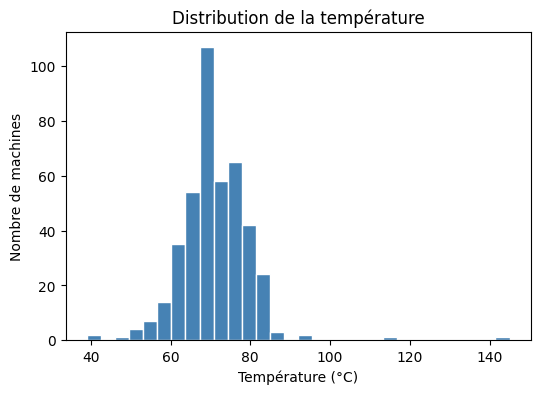

In [22]:
# 1. Histogramme : distribution de la température
plt.figure(figsize=(6, 4))
plt.hist(clean_df['temperature_C'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Température (°C)')
plt.ylabel("Nombre de machines")
plt.title("Distribution de la température")
plt.show()


/tmp/ipykernel_241/1528337771.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([clean_df.loc[clean_df['type_machine'] == t, 'vibration'] for t in types], labels=types)


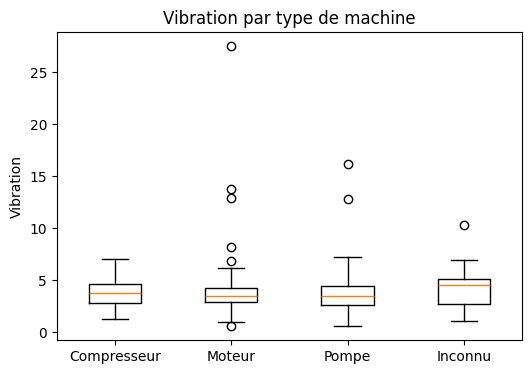

In [23]:
# 2. Boxplot : vibration par type de machine
plt.figure(figsize=(6, 4))
types = clean_df['type_machine'].unique()
plt.boxplot([clean_df.loc[clean_df['type_machine'] == t, 'vibration'] for t in types], labels=types)
plt.ylabel('Vibration')
plt.title("Vibration par type de machine")
plt.show()


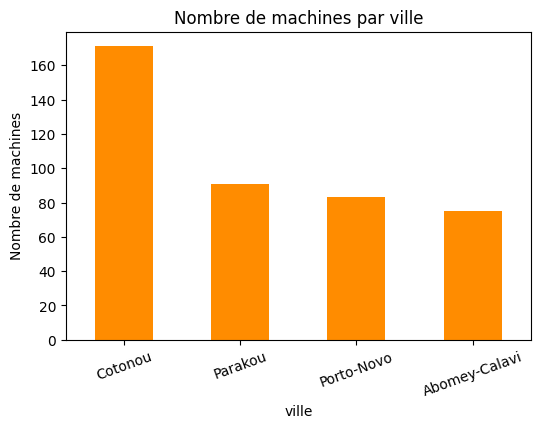

In [24]:
# 3. Barplot : nombre de machines par ville
plt.figure(figsize=(6, 4))
clean_df['ville'].value_counts().plot(kind='bar', color='darkorange')
plt.ylabel("Nombre de machines")
plt.title("Nombre de machines par ville")
plt.xticks(rotation=20)
plt.show()


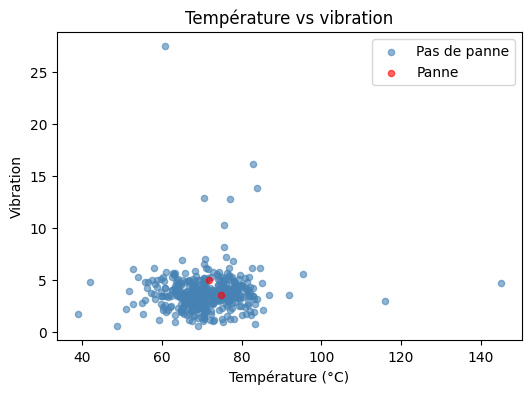

In [25]:
# 4. Scatterplot : température vs vibration, colorié par statut de panne
plt.figure(figsize=(6, 4))
for panne_val, couleur, label in [(0, 'steelblue', 'Pas de panne'), (1, 'red', 'Panne')]:
    subset = clean_df[clean_df['panne'] == panne_val]
    plt.scatter(subset['temperature_C'], subset['vibration'], c=couleur, label=label, alpha=0.6, s=20)
plt.xlabel('Température (°C)')
plt.ylabel('Vibration')
plt.title("Température vs vibration")
plt.legend()
plt.show()


### Conclusions attendues

**5 constats factuels :**
1. La base brute contient 423 lignes dont 3 doublons exacts, corrigés à 420 lignes uniques.
2. Les NA de `vibration` sont concentrés à 100 % sur Parakou (30,1 % des lignes de cette ville), un mécanisme MAR lié au site, alors que `temperature_C` et `pression_bar` sont manquantes de façon homogène entre villes (MCAR probable).
3. Deux valeurs de `vibration` sont négatives (-0.07, -0.23), ce qui est physiquement impossible pour un capteur de vibration ; elles ont été traitées comme invalides.
4. `panne` est très déséquilibrée (2 pannes sur 420 machines, soit 0,5 %) — un point critique à anticiper pour la modélisation du Jour 2 (classe minoritaire).
5. Les méthodes de détection d'outliers (IQR, Z-score, MAD, Isolation Forest) ne s'accordent pas toutes sur les mêmes machines : le Z-score, sensible aux valeurs extrêmes, sur-détecte légèrement par rapport au MAD, plus robuste.

**2 hypothèses à tester au Jour 2 :**
1. Les machines avec un `ecart_temperature_type` ou une `vibration` élevés ont-elles une probabilité de panne plus forte (même si la panne observée est rare, le signal pourrait apparaître en amont) ?
2. Le site de Parakou (celui qui a le plus de NA sur `vibration`) a-t-il un taux de panne ou des valeurs de capteurs structurellement différents des autres villes, suggérant un effet "site" à modéliser à part ?

**3 limites de la base :**
1. Seulement 2 pannes observées sur 420 machines : un modèle de classification aura très peu d'exemples positifs, la performance sera difficile à évaluer de façon fiable.
2. On ne connaît pas la cause de l'absence de `vibration` à Parakou (capteur, réseau, saisie manuelle ?) — l'hypothèse MAR reste une hypothèse métier, pas une certitude confirmée par des logs.
3. Les valeurs imputées (médiane globale ou par ville) réduisent artificiellement la variance réelle des variables ; toute conclusion statistique fine sur `temperature_C`, `vibration` ou `pression_bar` doit garder cette limite en tête au Jour 2.


## G. Export pour le Jour 2

In [26]:
# Export pour le Jour 2
clean_df.to_csv("../data/data_J1_clean.csv", index=False)
print(f"Fichier exporté : data_J1_clean.csv ({clean_df.shape[0]} lignes, {clean_df.shape[1]} colonnes)")


Fichier exporté : data_J1_clean.csv (420 lignes, 13 colonnes)
